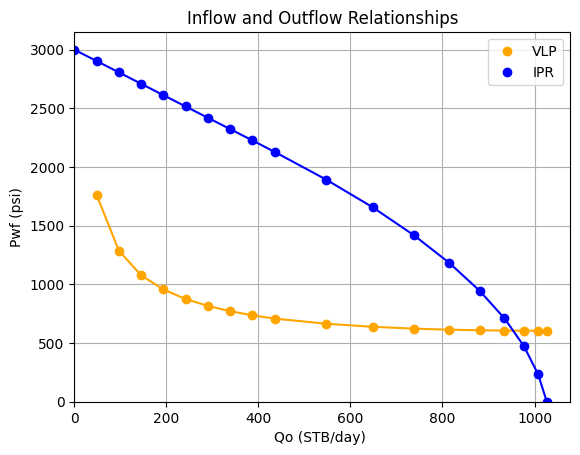

Operating Condition: ( Qo (STB/day), Pwf (psi) ) = (954.72, 605.95)
New Operating Condition: ( Qo (STB/day), Pwf (psi) ) = (1594.71, 594.20)


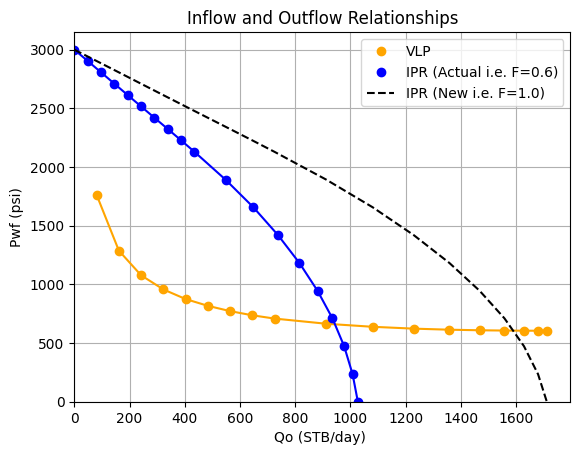

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import fsolve
%run IPR.ipynb
%run VLP.ipynb
%run Interpolation.ipynb
%run skin_effect.ipynb

In [4]:
# Effect of tubing
def tubing_effect(d_new):
    Pwf_array_VLP1 = Poettmann_and_Carpenter_Method(Pwh_VLP, T, d_new, API, GLR, Bw, fo, fw, Yg, Yo, Yw, Qo_array_VLP, depth)
    Pwf_predictator_VLP1 = splrep(Qo_array_VLP, Pwf_array_VLP1, k=3, s=9)
    Pwf_predicted_VLP1 = splev(Qo_array_VLP, Pwf_predictator_VLP1 )

    Qo , Pwf  = calculate_intersection(Pwf_predictator_VLP1, Pwf_predictator_IPR, initial_guess=500.0)

    # Create the plot
    plt.plot( Qo_array_VLP, Pwf_predicted_VLP, 'o', label=f'VLP with d={d} inch', color='orange')
    plt.plot(Qo_array_VLP, Pwf_predicted_VLP, '-', color='orange')
    plt.plot(Qo_array_VLP, Pwf_array_VLP1, '--',label=f'VLP with d={d_new} inch', color='black')
    plt.plot( Qo_array_IPR, Pwf_array_IPR, 'o', label=f'IPR', color='blue')
    plt.plot(Qo_array_IPR, Pwf_predicted_IPR, '-', color='blue')

    # Set the y-axis limits to start at the bottom of the well till top (inverted)
    plt.ylim(0, )
    plt.xlim(0, )

    # Customize labels and title
    plt.xlabel('Qo (STB/day) ')
    plt.ylabel('Pwf (psi)')
    plt.title('Inflow and Outflow Relationships')

    # Add a horizontal line at y=0 for better visualization of mirrored effect (optional)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

    # Adjust legend placement (optional)
    plt.legend(loc='upper right')

    # Display the plot
    plt.grid(True)
    plt.show()
    return Qo , Pwf

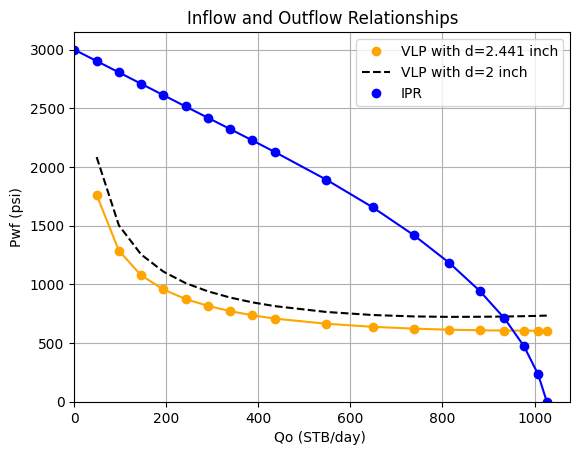

New Operating Condition: ( Qo (STB/day), Pwf (psi) ) = ( 931.58 , 725.77 )


In [5]:
p = tubing_effect(2)
print(f"New Operating Condition: ( Qo (STB/day), Pwf (psi) ) = ( {p[0]:.2f} , {p[1]:.2f} )")